Шаг 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})
print("Размер датасета:", df.shape)
print("\nТипы данных:\n", df.dtypes)
print("\nПропуски:\n", df.isnull().sum())
print("\nРаспределение классов:\n", df['target_name'].value_counts())
print("\nСтатистики:\n", df.describe())
plt.show()

Размер датасета: (150, 6)

Типы данных:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
target_name           object
dtype: object

Пропуски:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

Распределение классов:
 target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Статистики:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000 

Шаг 2 

In [5]:
X = df[iris.feature_names]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Шаг 3

Вопрос 1

Почему масштабирование важно для KNN?
KNN использует расстояния. Если один признак имеет больший размах, он будет доминировать в метрике. Масштабирование уравнивает вклад всех признаков.
Вопрос 2

Почему нельзя подбирать параметры на тестовой выборке?
Модель будет идеально обучена под конкретные данные.


Шаг 4 

In [6]:
knn_basic = KNeighborsClassifier(n_neighbors=3)
knn_basic.fit(X_train_scaled, y_train)
y_pred_basic = knn_basic.predict(X_test_scaled)

print("Базовый KNN (k=3) accuracy:", accuracy_score(y_test, y_pred_basic))

Базовый KNN (k=3) accuracy: 0.9333333333333333


Шаг 5 

10 лучших комбинаций параметров:
--------------------------------------------------
0.9667 - {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}
0.9583 - {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
0.9583 - {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

влияние k на accuracy
--------------------------------------------------
k=1: 0.9222
k=3: 0.9389
k=4: 0.9417
k=5: 0.9472
k=7: 0.9389
k=9: 0.9417
k=11: 0.9403
k=13: 0.9375
k=15

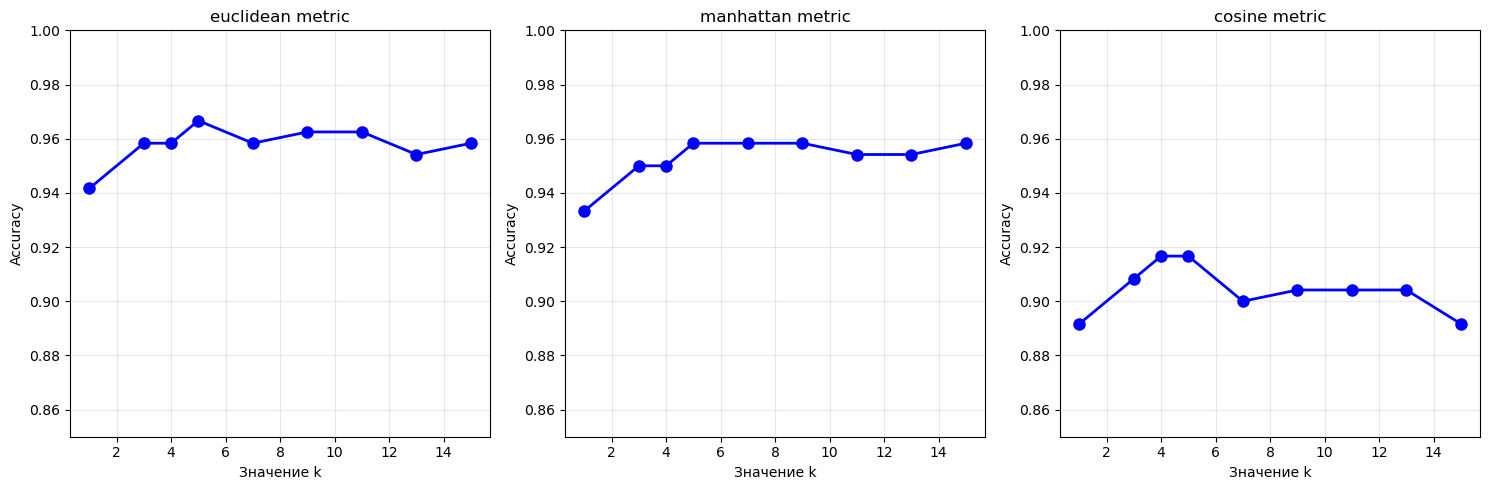


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучшая CV accuracy: 0.9667
Test accuracy: 0.9333


In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'n_neighbors': [1, 3, 4, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print("10 лучших комбинаций параметров:")
print("-" * 50)
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = results_df.nlargest(10, 'mean_test_score')[['params', 'mean_test_score']]
for idx, row in top10.iterrows():
    print(f"{row['mean_test_score']:.4f} - {row['params']}")

print("\nвлияние k на accuracy")
print("-" * 50)
k_values = sorted(param_grid['n_neighbors'])
for k in k_values:
    mask = results_df['param_n_neighbors'] == k
    mean_acc = results_df[mask]['mean_test_score'].mean()
    print(f"k={k}: {mean_acc:.4f}")
print("\nвлияние weights на accuracy")
print("-" * 50)
for w in param_grid['weights']:
    mask = results_df['param_weights'] == w
    mean_acc = results_df[mask]['mean_test_score'].mean()
    print(f"{w}: {mean_acc:.4f}")

print("\nвлияние metrics на accuracy")
print("-" * 50)
for m in param_grid['metric']:
    mask = results_df['param_metric'] == m
    mean_acc = results_df[mask]['mean_test_score'].mean()
    print(f"{m}: {mean_acc:.4f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['euclidean', 'manhattan', 'cosine']

for idx, metric in enumerate(metrics):
    mask = results_df['param_metric'] == metric
    data = results_df[mask].groupby('param_n_neighbors')['mean_test_score'].mean()
    
    axes[idx].plot(data.index, data.values, 'bo-', linewidth=2, markersize=8)
    axes[idx].set_title(f'{metric} metric', fontsize=12)
    axes[idx].set_xlabel('Значение k', fontsize=10)
    axes[idx].set_ylabel('Accuracy', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()
print("\n" + "="*50)
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая CV accuracy: {grid_search.best_score_:.4f}")
best_knn = grid_search.best_estimator_
test_acc = best_knn.score(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.4f}")